<a href="https://colab.research.google.com/github/UMIDATA77/CCFD-with-ML-algorithms/blob/main/COW_Pose_Estimation_YOLOv8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using Colab cache for faster access to the 'cow-pose-estimation-dataset' dataset.
Path to dataset files: /kaggle/input/cow-pose-estimation-dataset


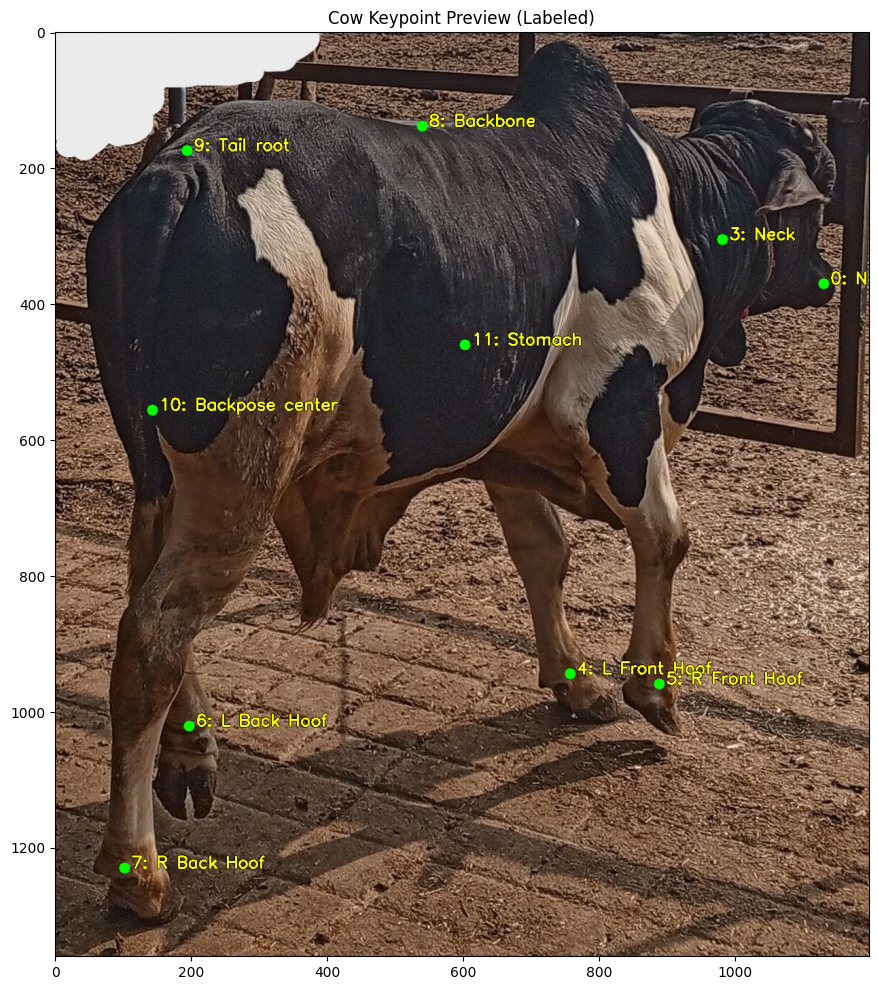

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt
import glob
import kagglehub

# Download latest version
path = kagglehub.dataset_download("zaidworks0508/cow-pose-estimation-dataset")

print("Path to dataset files:", path)

dataset_path = os.path.join(path, "Cow Pose Estimation")

image_folder = os.path.join(dataset_path, "images", "train")

label_folder = os.path.join(dataset_path, "labels", "train")

keypoint_names = [
    "Nose", "Right Eye", "Left Eye", "Neck",
    "L Front Hoof", "R Front Hoof", "L Back Hoof", "R Back Hoof",
    "Backbone", "Tail root", "Backpose center", "Stomach"
]


image_files = glob.glob(os.path.join(image_folder, "*.jpg"))
if not image_files:
    print(f"ERROR: No images found at {image_folder}. Check folder paths.")
else:
    img_path = image_files[0]

    basename = os.path.basename(img_path).replace('.jpg', '.txt')
    label_path = os.path.join(label_folder, basename)

    if os.path.exists(label_path):
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w, _ = img.shape

        with open(label_path, 'r') as f:
            lines = f.readlines()

        for line in lines:
            parts = list(map(float, line.strip().split()))
            keypoints = parts[5:]


            for i in range(0, len(keypoints), 3):
                kx, ky = keypoints[i], keypoints[i+1]


                cx, cy = int(kx * w), int(ky * h)

                if cx > 0 and cy > 0:
                    cv2.circle(img, (cx, cy), 8, (0, 255, 0), -1)

                    # Print name
                    kp_idx = i // 3
                    if kp_idx < len(keypoint_names):
                        label = f"{kp_idx}: {keypoint_names[kp_idx]}"
                        # Add black outline to make text more visible
                        cv2.putText(img, label, (cx + 10, cy), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 0), 4)
                        cv2.putText(img, label, (cx + 10, cy), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 0), 2)

        plt.figure(figsize=(12,12))
        plt.imshow(img)
        plt.title("Cow Keypoint Preview (Labeled)")
        plt.show()
    else:
        print("Label file not found. Dataset format might be different (e.g., COCO JSON).")

In [ ]:
# List the actual folder structure of the dataset
print(f"Dataset path: {dataset_path}")
!ls -R "{dataset_path}"

Dataset path: /kaggle/input/cow-pose-estimation-dataset/Cow Pose Estimation
'/kaggle/input/cow-pose-estimation-dataset/Cow Pose Estimation':
backgrounds  images  labels  metadata.txt

'/kaggle/input/cow-pose-estimation-dataset/Cow Pose Estimation/backgrounds':
'backgrounds (100).jpg'  'backgrounds (35).jpg'  'backgrounds (69).jpg'
'backgrounds (101).jpg'  'backgrounds (36).jpg'  'backgrounds (6).jpg'
'backgrounds (102).jpg'  'backgrounds (37).jpg'  'backgrounds (70).jpg'
'backgrounds (103).jpg'  'backgrounds (38).jpg'  'backgrounds (71).jpg'
'backgrounds (104).jpg'  'backgrounds (39).jpg'  'backgrounds (72).jpg'
'backgrounds (105).jpg'  'backgrounds (3).jpg'	 'backgrounds (73).jpg'
'backgrounds (106).jpg'  'backgrounds (40).jpg'  'backgrounds (74).jpg'
'backgrounds (10).jpg'	 'backgrounds (41).jpg'  'backgrounds (75).jpg'
'backgrounds (11).jpg'	 'backgrounds (42).jpg'  'backgrounds (76).jpg'
'backgrounds (12).jpg'	 'backgrounds (43).jpg'  'backgrounds (77).jpg'
'backgrounds (13).jpg'	 

In [ ]:
%pip install ultralytics
import ultralytics
ultralytics.checks() # Checks if GPU is active

Ultralytics 8.4.11 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 38.7/235.7 GB disk)


In [ ]:
import os
import yaml

# Base path where the dataset is downloaded
base_kaggle_path = "/root/.cache/kagglehub/datasets/zaidworks0508/cow-pose-estimation-dataset/versions/1"

# Root directory containing actual 'images' and 'labels' folders
# According to ls output, images are in 'Cow Pose Estimation' subfolder.
dataset_root_for_yolo = os.path.join(base_kaggle_path, "Cow Pose Estimation")

# Check if 'valid' directory exists inside 'images'
has_valid_split = os.path.exists(os.path.join(dataset_root_for_yolo, "images", "valid"))

# YAML content
yaml_content = {
    'path': dataset_root_for_yolo,  # Root directory
    'train': 'images/train',        # Training images, relative to 'path'
    'val': 'images/valid' if has_valid_split else 'images/train', # Validation images, relative to 'path'

    # Keypoint Information
    'kpt_shape': [12, 3],  # 12 points, each containing (x, y, visibility)
    'names': {
        0: 'cow' # We have a single class: Cow
    }
}

# Create and save a file named cow_pose.yaml
yaml_file = 'cow_pose.yaml'
with open(yaml_file, 'w') as f:
    yaml.dump(yaml_content, f, sort_keys=False)

print(f"Config file created: {os.path.abspath(yaml_file)}")
print("Content:", yaml_content)

Config file created: /content/cow_pose.yaml
Content: {'path': '/root/.cache/kagglehub/datasets/zaidworks0508/cow-pose-estimation-dataset/versions/1/Cow Pose Estimation', 'train': 'images/train', 'val': 'images/train', 'kpt_shape': [12, 3], 'names': {0: 'cow'}}


In [ ]:
from ultralytics import YOLO
import os
import yaml

# Re-create cow_pose.yaml with the correct path
# Use the global 'dataset_path' variable which is '/kaggle/input/cow-pose-estimation-dataset/Cow Pose Estimation'
# This path was verified by 'ls -R' to contain 'images/train'

# Check if 'images/valid' exists under the correct dataset_path
has_valid_split = os.path.exists(os.path.join(dataset_path, "images", "valid"))

# YAML content, using dataset_path
yaml_content = {
    'path': dataset_path, # CORRECTED: Use dataset_path
    'train': 'images/train',
    'val': 'images/valid' if has_valid_split else 'images/train',

    'kpt_shape': [12, 3],
    'names': {
        0: 'cow'
    }
}

yaml_file = 'cow_pose.yaml'
with open(yaml_file, 'w') as f:
    yaml.dump(yaml_content, f, sort_keys=False)

print(f"Updated config file generated: {os.path.abspath(yaml_file)}")
print("Updated content:", yaml_content)

model = YOLO('yolov8m-pose.pt')

results = model.train(
    data=yaml_file, # Use the re-generated yaml_file
    epochs=100,
    imgsz=640,
    batch=8,
    project='cow_project_v2', # Translated from inek_projesi_v2
    name='cow_medium_model',   # Translated from inek_medium_model

    # (Augmentation)
    degrees=15.0,
    fliplr=0.5,
    scale=0.5,
    mosaic=1.0,
)

Updated config file generated: /content/cow_pose.yaml
Updated content: {'path': '/kaggle/input/cow-pose-estimation-dataset/Cow Pose Estimation', 'train': 'images/train', 'val': 'images/train', 'kpt_shape': [12, 3], 'names': {0: 'cow'}}
Ultralytics 8.4.11 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=cow_pose.yaml, degrees=15.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4

Loading model: /content/runs/pose/cow_project_v2/cow_medium_model/weights/best.pt

image 1/1 /kaggle/input/cow-pose-estimation-dataset/Cow Pose Estimation/images/train/Riz MM (4).jpg: 480x640 1 cow, 77.2ms
Speed: 4.1ms preprocess, 77.2ms inference, 1.9ms postprocess per image at shape (1, 3, 480, 640)


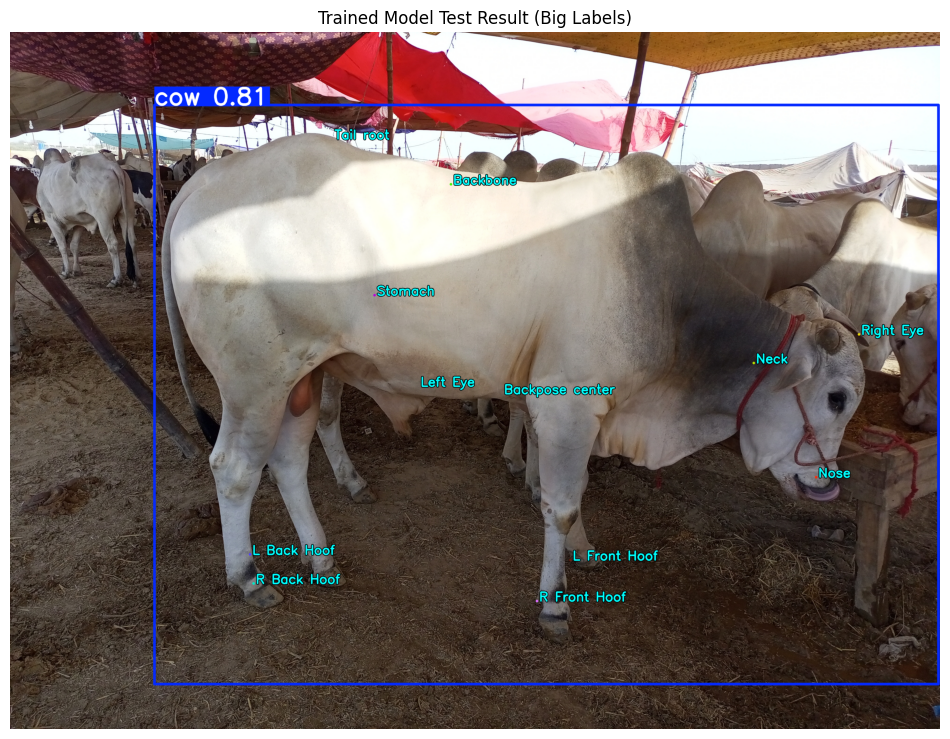

In [ ]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import glob
import os

runs_path = '/content/runs/pose/cow_project_v2' # Updated path
latest_run = sorted(os.listdir(runs_path))[-1]
best_model_path = os.path.join(runs_path, latest_run, 'weights', 'best.pt')

print(f"Loading model: {best_model_path}")
model = YOLO(best_model_path)

# 2. Select a random image to test
# Use dataset_path from the first cell to be safe
test_image_folder = os.path.join(dataset_path, "images", "train")
test_images = glob.glob(os.path.join(test_image_folder, "*.jpg"))

if test_images:
    # Ensure we don't go out of bounds if there are fewer than 6 images
    idx = 5 if len(test_images) > 5 else 0
    test_img_path = test_images[idx]

    # 3. Predict
    results = model(test_img_path)

    # 4. Show Result
    # Ultralytics result object has a plotting function
    res_plotted = results[0].plot()

    # Get keypoint data and print names
    if results[0].keypoints is not None:
        # Get keypoint coordinates of the first detected object (cow)
        keypoints = results[0].keypoints.xy.cpu().numpy()[0]

        # Name list
        keypoint_names = [
            "Nose", "Right Eye", "Left Eye", "Neck",
            "L Front Hoof", "R Front Hoof", "L Back Hoof", "R Back Hoof",
            "Backbone", "Tail root", "Backpose center", "Stomach"
        ]

        # Write names on the image
        for i, (x, y) in enumerate(keypoints):
            if x > 0 and y > 0: # If valid point (not 0,0)
                if i < len(keypoint_names):
                    label = keypoint_names[i]
                    # For visible text: Thick black outline first, then colored text
                    cv2.putText(res_plotted, label, (int(x)+10, int(y)), cv2.FONT_HERSHEY_SIMPLEX, 1.8, (0, 0, 0), 12)
                    cv2.putText(res_plotted, label, (int(x)+10, int(y)), cv2.FONT_HERSHEY_SIMPLEX, 1.8, (255, 255, 0), 6)

    plt.figure(figsize=(12,12))
    plt.imshow(cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB))
    plt.title("Trained Model Test Result (Big Labels)")
    plt.axis('off')
    plt.show()
else:
    print("No image found to test.")